# Sentiment Analysis

Load processed comments with preprocessed text variants from the preprocessing notebook.

In [20]:
import json
from pathlib import Path
from collections import Counter
import nltk
import matplotlib.pyplot as plt
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
from transformers import pipeline
from transformers import AutoModelForSequenceClassification, AutoTokenizer

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_VIDEO_DATA_PATH = DATA_DIR / "video_data_processed.json"


In [21]:

with open(PROCESSED_VIDEO_DATA_PATH, "r", encoding="utf-8") as f:
    processed_video_data = json.load(f)

processed_comments = processed_video_data["comments"]
print(f"Loaded {len(processed_comments)} processed comments\n")

Loaded 46939 processed comments



In [22]:
SENTIMENT_TEXT_FIELD = "comment_text_sentiment_analysis"
TOTAL_EXAMPLES = 10

print("SENTIMENT ANALYSIS TEXT EXAMPLES")
print("=" * 80)
processed_data = processed_comments
for comment in processed_comments[:TOTAL_EXAMPLES]:
    print(f"\nID: {comment.get('comment_id')}")
    print(f"Original: {comment.get('comment_text')}")
    print(f"For VADER: {comment.get(SENTIMENT_TEXT_FIELD)}")


SENTIMENT ANALYSIS TEXT EXAMPLES

ID: Ugx4TmtthtmdHtePwqV4AaABAg
Original: The whole thing is so phoney STIFF UNNATURAL SMILES..some.unimaginative outfits...so pretenscious all this money spent could have fed the world!..
For VADER: The whole thing is so phoney STIFF UNNATURAL SMILES..some.unimaginative outfits...so pretenscious all this money spent could have fed the world!..

ID: Ugylw87AQ2Q4CkseUkt4AaABAg
Original: Free the CHILDREN
For VADER: Free the CHILDREN

ID: UgxGdNOPXiLmPW4AD4R4AaABAg
Original: Thank you so much 🎉🎉🎉🎉🎉🎉🎉🎉🎉❤❤❤❤❤❤
For VADER: Thank you so much 🎉🎉🎉🎉🎉🎉🎉🎉🎉❤❤❤❤❤❤

ID: Ugz8mOUwbqV8xANIC-F4AaABAg
Original: Thanks, it's an extraordinary event with so many amazing gowns. ❤❤❤
For VADER: Thanks, it's an extraordinary event with so many amazing gowns. ❤❤❤

ID: UgyQpepxkSysJf72hn94AaABAg
Original: Why that song?
For VADER: Why that song?

ID: UgwuNhzfeMcNr7V5liF4AaABAg
Original: When the Queen, Beyoncé showed up, the crowd went crazy! ❤❤❤❤❤❤❤❤❤❤
For VADER: When the Queen, B

In [ ]:
VADER_POSITIVE_THRESHOLD = 0.05
VADER_NEGATIVE_THRESHOLD = -0.05
SENTIMENT_RESULTS_PATH = DATA_DIR / "sentiment_results_by_comment_id.json"

BERT_SENTIMENT_FIELDS = [
    "bert_sentiment",
    "bert_sentiment_raw",
    "bert_confidence",
    "bert_negative",
    "bert_neutral",
    "bert_positive",
]

In [ ]:

loaded_sentiment_results = SENTIMENT_RESULTS_PATH.exists()

if loaded_sentiment_results:
    with SENTIMENT_RESULTS_PATH.open("r", encoding="utf-8") as f:
        sentiment_results_by_comment_id = json.load(f)
else:
    sentiment_results_by_comment_id = {}


In [24]:
def label_vader_sentiment(compound_score):
    if compound_score >= VADER_POSITIVE_THRESHOLD:
        return "positive"
    if compound_score <= VADER_NEGATIVE_THRESHOLD:
        return "negative"
    return "neutral"

def vader_sentiment_analysis(processed_data):
    """
    Use VADER lexicon for sentiment analysis on processed YouTube comment data.

    @param processed_data: list of dicts with comment text and published date keys
    @returns: list of VADER sentiment result dicts, aligned to processed_data order
    """
    sent_analyser = SentimentIntensityAnalyzer()
    sentiment_results = []

    for entry in processed_data:
        vader_text = entry[SENTIMENT_TEXT_FIELD]
        post_date = entry.get("comment_published_at", None)
        scores = sent_analyser.polarity_scores(vader_text)
        compound_score = scores["compound"]

        sentiment_results.append({
            "comment_id": entry.get("comment_id"),
            "published_at": post_date,
            "vader_compound": compound_score,
            "vader_sentiment": label_vader_sentiment(compound_score),
        })
    return sentiment_results


In [25]:
if not loaded_sentiment_results:
    vader_sentiment = vader_sentiment_analysis(processed_data)

    for result in vader_sentiment:
        sentiment_results_by_comment_id[result["comment_id"]] = {
            "published_at": result["published_at"],
            "vader_compound": result["vader_compound"],
            "vader_sentiment": result["vader_sentiment"],
        }



In [26]:
for row in processed_data:
    result = sentiment_results_by_comment_id[row["comment_id"]]
    row["vader_sentiment"] = result["vader_sentiment"]

vader_sentiment = [
    {"comment_id": comment_id, **result}
    for comment_id, result in sentiment_results_by_comment_id.items()
]
vader_series = pd.Series(result["vader_compound"] for result in vader_sentiment)


In [27]:

vader_sentiment_counter = Counter(row["vader_sentiment"] for row in processed_data)

print("VADER SENTIMENT SUMMARY")
print("=" * 80)
print(f"Analysed comments: {len(vader_sentiment)}")
for label, count in vader_sentiment_counter.most_common():
    pct = 100 * count / len(processed_data)
    print(f"{label}: {count:,} ({pct:.2f}%)")


VADER SENTIMENT SUMMARY
Analysed comments: 46809
positive: 21,807 (46.46%)
neutral: 14,352 (30.58%)
negative: 10,780 (22.97%)


In [28]:
SENTIMENT_ORDER = ["negative", "neutral", "positive"]
SENTIMENT_COLORS = {
    "positive": "#32cd32",    # lime
    "neutral": "#bdbdbd",     # light grey
    "negative": "#ff6347",    # tomato
}
SENTIMENT_FREE_COLOR = "magenta"

## 1. Sentiment Distribution

Baseline count of positive, neutral, and negative VADER labels.

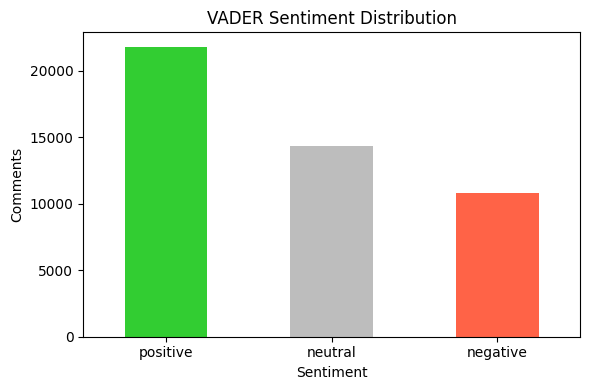

In [29]:
# Sentiment dataframe
sentiment_df = pd.DataFrame(processed_data).copy()

# Convert comment_published_at to datetime with error handling
sentiment_df["comment_published_at"] = pd.to_datetime(sentiment_df["comment_published_at"], errors="coerce")

# Count how many comments fall into each VADER sentiment category
sentiment_counts = sentiment_df["vader_sentiment"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax = sentiment_counts.plot(
    kind="bar",
    ax=ax,
    color=[SENTIMENT_COLORS[label] for label in sentiment_counts.index],
    rot=0,
    title="VADER Sentiment Distribution",
)
ax.set_xlabel("Sentiment")
ax.set_ylabel("Comments")
plt.tight_layout()


## 2. Sentiment Over Time

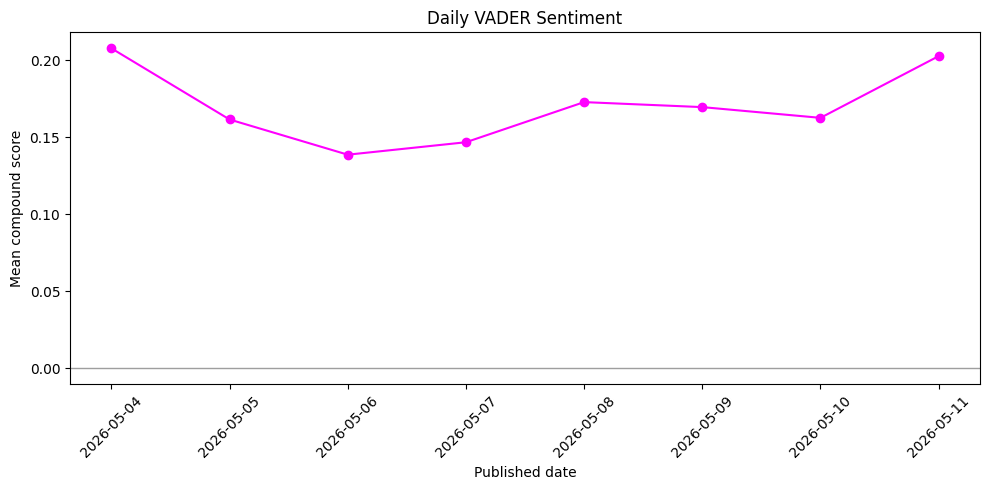

In [30]:
vader_sentiment_df = pd.DataFrame(vader_sentiment).dropna(subset=["published_at"]).copy()
vader_sentiment_df["published_date"] = pd.to_datetime(vader_sentiment_df["published_at"]).dt.date

daily_sentiment = vader_sentiment_df.groupby("published_date")["vader_compound"].mean().reset_index(name="mean_compound")
daily_sentiment["published_date"] = daily_sentiment["published_date"].astype(str)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(daily_sentiment["published_date"], daily_sentiment["mean_compound"], marker="o", color=SENTIMENT_FREE_COLOR)
ax.set_title("Daily VADER Sentiment")
ax.set_xlabel("Published date")
ax.set_ylabel("Mean compound score")
ax.axhline(0, color="#9e9e9e", linewidth=1)
ax.tick_params(axis="x", labelrotation=45)
plt.tight_layout()


## 3. Sentiment by Entity

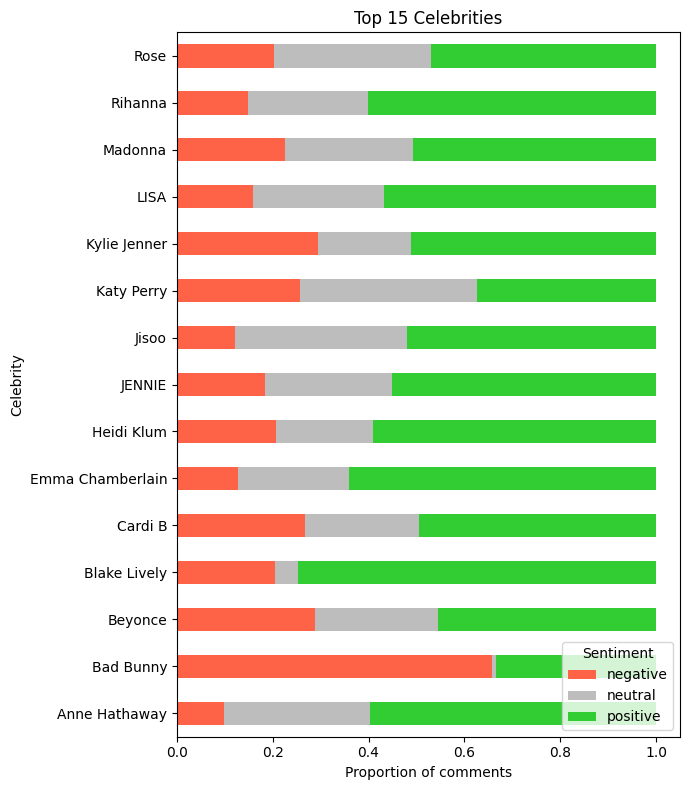

In [31]:

TOP_CELEB_COUNT = 15

celeb_rows = sentiment_df.explode("celebs").dropna(subset=["celebs"])
top_celebs = celeb_rows["celebs"].value_counts().head(TOP_CELEB_COUNT).index
celeb_sentiment = (
    celeb_rows[celeb_rows["celebs"].isin(top_celebs)]
    .groupby(["celebs", "vader_sentiment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SENTIMENT_ORDER, fill_value=0)
)
celeb_sentiment_share = celeb_sentiment.div(celeb_sentiment.sum(axis=1), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(7, 8))
celeb_sentiment_share.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=[SENTIMENT_COLORS[label] for label in celeb_sentiment_share.columns],
    title=f"Top {TOP_CELEB_COUNT} Celebrities",
)
ax.set_xlabel("Proportion of comments")
ax.set_ylabel("Celebrity")
ax.legend(title="Sentiment", loc="lower right")
plt.tight_layout()
plt.show()



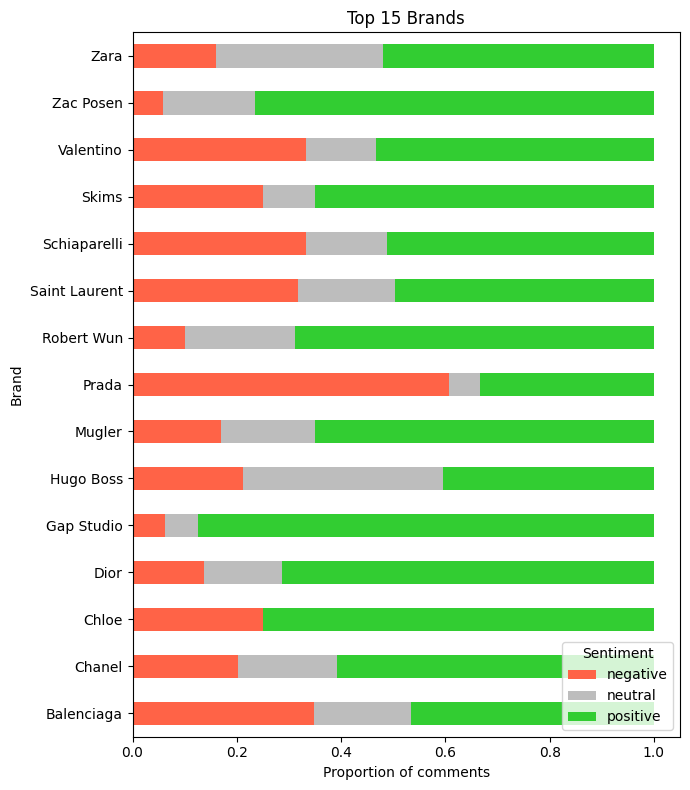

In [32]:

TOP_BRAND_COUNT = 15
brand_rows = sentiment_df.explode("brands").dropna(subset=["brands"])
top_brands = brand_rows["brands"].value_counts().head(TOP_BRAND_COUNT).index
brand_sentiment = (
    brand_rows[brand_rows["brands"].isin(top_brands)]
    .groupby(["brands", "vader_sentiment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SENTIMENT_ORDER, fill_value=0)
)
brand_sentiment_share = brand_sentiment.div(brand_sentiment.sum(axis=1), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(7, 8))
brand_sentiment_share.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=[SENTIMENT_COLORS[label] for label in brand_sentiment_share.columns],
    title=f"Top {TOP_BRAND_COUNT} Brands",
)
ax.set_xlabel("Proportion of comments")
ax.set_ylabel("Brand")
ax.legend(title="Sentiment", loc="lower right")
plt.tight_layout()
plt.show()


## 5. Entity Mention Frequency

Most-mentioned celebrities and brands, used as context for interpreting entity sentiment.

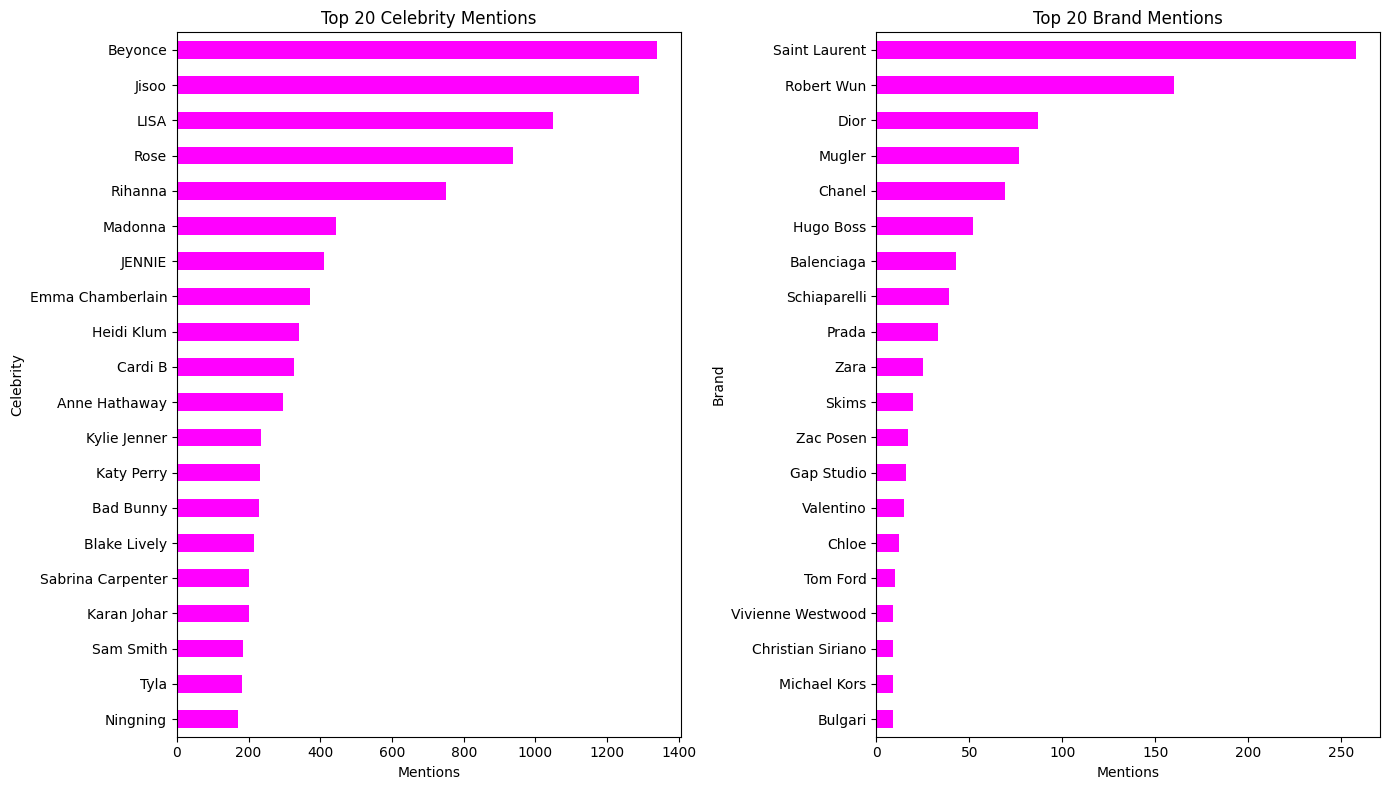

In [ ]:
from tkinter.constants import SE

TOP_MENTION_COUNT = 20
celeb_counts = celeb_rows["celebs"].value_counts().head(TOP_MENTION_COUNT).sort_values()
brand_counts = brand_rows["brands"].value_counts().head(TOP_MENTION_COUNT).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
celeb_counts.plot(
    kind="barh",
    ax=axes[0],
    color=SENTIMENT_FREE_COLOR,
    title=f"Top {TOP_MENTION_COUNT} Celebrity Mentions",
)
brand_counts.plot(
    kind="barh",
    ax=axes[1],
    color=SENTIMENT_FREE_COLOR,
    title=f"Top {TOP_MENTION_COUNT} Brand Mentions",
)
axes[0].set_xlabel("Mentions")
axes[0].set_ylabel("Celebrity")
axes[1].set_xlabel("Mentions")
axes[1].set_ylabel("Brand")
plt.tight_layout()


## BERT-based Sentiment Analysis

In [34]:
BERT_SENTIMENT_MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
BERT_SENTIMENT_MODEL_NAME = "cardiffnlp-twitter-roberta-base-sentiment-latest"
BERT_SENTIMENT_MODEL_DIR = PROJECT_ROOT / "models" / BERT_SENTIMENT_MODEL_NAME
HF_CACHE_DIR = PROJECT_ROOT / ".cache" / "huggingface"
BERT_CONFIDENCE_THRESHOLD = 0.60
BERT_BATCH_SIZE = 32


In [41]:

# Make model directory and download model if it doesn't exist
if not BERT_SENTIMENT_MODEL_DIR.exists():
    model = AutoModelForSequenceClassification.from_pretrained(BERT_SENTIMENT_MODEL)
    tokenizer = AutoTokenizer.from_pretrained(BERT_SENTIMENT_MODEL)
    BERT_SENTIMENT_MODEL_DIR.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(BERT_SENTIMENT_MODEL_DIR)
    tokenizer.save_pretrained(BERT_SENTIMENT_MODEL_DIR)
    print(f"Downloaded and saved model to: {BERT_SENTIMENT_MODEL_DIR}")
else:
    print(f"Loaded model from: {BERT_SENTIMENT_MODEL_DIR}")


Loaded model from: /Users/cooper/Documents/GitHub/Network-Analysis-Project#/models/cardiffnlp-twitter-roberta-base-sentiment-latest


In [36]:
# Initialize the BERT-based sentiment analysis pipeline
sentiment_model = pipeline(
    "text-classification",
    model=str(BERT_SENTIMENT_MODEL_DIR),
    tokenizer=str(BERT_SENTIMENT_MODEL_DIR),
    return_all_scores=True,
    top_k=None,
    truncation=True,
    max_length=512,
    cache_dir=str(HF_CACHE_DIR),
)


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 17450.94it/s]


In [37]:
# Model defined labels 
def normalise_bert_label(label):
    label = label.lower()
    label_map = {
        "label_0": "negative",
        "label_1": "neutral",
        "label_2": "positive",
    }
    return label_map.get(label, label)

# BERT sentiment analysis
def bert_sentiment_analysis(processed_data, threshold=BERT_CONFIDENCE_THRESHOLD):
    texts = [entry.get(SENTIMENT_TEXT_FIELD, "") for entry in processed_data]
    bert_predictions = sentiment_model(texts, batch_size=BERT_BATCH_SIZE)
    
    results = []
    for entry, scores in zip(processed_data, bert_predictions):

        # Map model labels to readable strings and collect scores
        scores_map = {normalise_bert_label(s["label"]): s["score"] for s in scores}
        top_label = max(scores_map, key=scores_map.get)
        confidence = scores_map[top_label]
        label = top_label if confidence >= threshold else "unknown"

        results.append({
            "comment_id": entry.get("comment_id"),
            "bert_sentiment": label,
            "bert_sentiment_raw": top_label,
            "bert_confidence": round(confidence, 4),
            "bert_negative": round(scores_map.get("negative", 0.0), 4),
            "bert_neutral": round(scores_map.get("neutral", 0.0), 4),
            "bert_positive": round(scores_map.get("positive", 0.0), 4),
        })
    return results

In [40]:
if not loaded_sentiment_results:
    bert_sentiment = bert_sentiment_analysis(processed_data)

    for result in bert_sentiment:
        comment_id = result["comment_id"]
        bert_fields = {key: value for key, value in result.items()}
        sentiment_results_by_comment_id[comment_id].update(bert_fields)

    with SENTIMENT_RESULTS_PATH.open("w", encoding="utf-8") as f:
        json.dump(sentiment_results_by_comment_id, f, ensure_ascii=False, indent=2)

for row in processed_data:
    result = sentiment_results_by_comment_id[row["comment_id"]]
    row.update({field: result[field] for field in BERT_SENTIMENT_FIELDS})


In [51]:
bert_counter = Counter(row["bert_sentiment"] for row in processed_data)

print("BERT SENTIMENT SUMMARY")
print(80 * "=")
print(f"Analysed comments: {len(bert_sentiment)}")
for label, count in bert_counter.most_common():
    pct = 100 * count / len(processed_data)
    print(f"{label}: {count:,} ({pct:.2f}%)")


BERT SENTIMENT SUMMARY
Analysed comments: 46939
positive: 14,705 (31.33%)
negative: 14,252 (30.36%)
unknown: 9,047 (19.27%)
neutral: 8,935 (19.04%)


In [55]:
TOTAL_EXAMPLES = 10

def print_bert_sentiment_examples(label, total_examples=TOTAL_EXAMPLES):
    examples = [row for row in processed_data if row["bert_sentiment"] == label]
    upper_label = label.upper()
    print(f"\nBERT {upper_label} SENTIMENT EXAMPLES")
    print(80 * "=")
    for example in examples[:total_examples]:
        print("-", example[SENTIMENT_TEXT_FIELD])

print_bert_sentiment_examples("positive")
print_bert_sentiment_examples("negative")



BERT POSITIVE SENTIMENT EXAMPLES
- Thank you so much 🎉🎉🎉🎉🎉🎉🎉🎉🎉❤❤❤❤❤❤
- Thanks, it's an extraordinary event with so many amazing gowns. ❤❤❤
- When the Queen, Beyoncé showed up, the crowd went crazy! ❤❤❤❤❤❤❤❤❤❤
- Beyonce art wear is extraordinary.❤❤❤
- Kardashians looking great, Mom, the head of the family wearing a fabulous Kimono, it's amazing. ❤❤❤
- Everyone looks outstanding, so much creative art and unique designs. I love Cher black outfit with her leather and bright shiny materials. Cher stands out always. ❤❤❤
- West African Doechi representing "dark female energy" is superb. I love her unique outfit.❤❤❤
- I love fashion..
- Beyonce gala look is literally her dangerously in love album cover meets 2026 evolution 😉👑
- - Cher (The Queen!)

BERT NEGATIVE SENTIMENT EXAMPLES
- The whole thing is so phoney STIFF UNNATURAL SMILES..some.unimaginative outfits...so pretenscious all this money spent could have fed the world!..
- We missed figure skater, cause those ladies are just talking and

In [54]:

print_bert_sentiment_examples("neutral")
print_bert_sentiment_examples("unknown")



BERT NEUTRAL SENTIMENT EXAMPLES
- wonder whats on the menu um who?
- when does emma chaimberlain come
- my cousin
- where is a Rianna???
- Did Venus Williams receive a wild card to enter this event ?
- Group meditation. I need her name , what's her name again??
- Nobody was talking about Finn Wolfhard 🥲
- 90% kpop comments 10% other comments 😂
- Is this a Circus or what??
- The Hunger Games

BERT UNKNOWN SENTIMENT EXAMPLES
- Free the CHILDREN
- Why that song?
- Society satanists
- 
- All glitzed out but no class.
- Eyes wide shut done made them do this we all kno what they be doing inside
- WHAT IS IT?!!!
- Can never touch the Queen Whitney Houston
- Zac Posen And Kendall Jenner stole the show, THE END
- If they needa go pee😂😂😂😂😂


In [ ]:
# Find all rows where matches occurred between methods and return final set of rows
matching_rows = []
for row in processed_data:
    if row["bert_sentiment"] == row["vader_sentiment"]:
        matching_rows.append(row)


In [58]:
matching_counter = Counter(row["bert_sentiment"] for row in matching_rows)

print("MATCHING SENTIMENT CLASSIFICATIONS")
print(80 * "=")
print(f"Analysed comments: {len(matching_rows)}")
for label, count in matching_counter.most_common():
    print(f"{label}: {count:,}")



MATCHING SENTIMENT CLASSIFICATIONS
Analysed comments: 23761
positive: 10,864
negative: 7,418
neutral: 5,479
